<a href="https://colab.research.google.com/github/cemreyavuzbounbos/Pricing-and-Hedging-of-Arithmetic-Asian-Options/blob/main/Pricing_and_Hedging_of_Arithmetic_Asian_Options.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pricing and Hedging of Arithmetic Asian Options under the Black–Scholes Framework

**Spring 2026 Introduction to Quantiative Methods in Finance**

**The Erdös Institute**

In [26]:
#Package Import
import numpy as np
import pandas as pd
import yfinance as yf
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.stats import shapiro
import scipy.stats as stats
from scipy.optimize import brentq
from mpl_toolkits.mplot3d import Axes3D
sns.set_style('darkgrid')

def bs_call(S0, K, sigma, T, r):
    """
    Calculates the Black-Scholes price of a European call option.
    """
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

def bs_put(S0, K, sigma, T, r):
    """
    Calculates the Black-Scholes price of a European put option.
    """
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    # Corrected Put formula: K*exp(-rT)*N(-d2) - S0*N(-d1)
    put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
    return put_price

An Asian option is one whose payoff includes a time average of the underlying asset price.

The standard assumption in pricing Asian options is that the underlying asset price follows a geometric Brownian motion under the risk-neutral measure, consistent with the Black–Scholes–Merton framework. This assumption is used in the classic analyses of Asian options by Kemna and Vorst (1990), Turnbull and Wakeman (1991), and in textbooks such as Hull (2022) and Glasserman (2004).

Option's payoff depends on the average of the prices along the path. Let's examine this more carefully. The underlying stock $S_t$ is lognormally distributed by the assumption. For any $0 \le t \le T$,  
$$
\ln S_t \sim \mathcal{N}\Big(\ln S_0 + (r - \tfrac{1}{2}\sigma^2) t,\; \sigma^2 t\Big)
$$



where $T$ is the time to expiration. The Black--Scholes formula assumes that the option payoff depends on a lognormal variable at expiration, which allows the expected payoff to be computed analytically. **However, the arithmetic average
$$
A_T = \frac{1}{T}\int_0^T S_t \, dt
$$  
is the integral of lognormal variables, and the lognormal distribution is not closed under addition , i.e. $\int_0^T S_t \, dt$ is not lognormal. Since the lognormal distribution is closed under multiplication by a positive constant, $A_T$ is not lognormal either.**

The distribution of the arithmetic average has no simple analytic form, and the standard Black-Scholes formula or other closed-form option pricing formulas do not apply. Monte Carlo simulation or numerical approximation methods are therefore required for valuation.


**Note : The primary reason to base an option payoff on an average asset price is to make it more difficult for anyone to significantly affect the payoff by manipulation of the underlying asset price.**

## **Economic Intuition Behind the Math**

Averaging is essentially a "volatility dampener." Because the average price is less likely to have extreme swings than the final price, Asian options are almost always cheaper than European options. If we find the Asian price is higher than the European price, there's a bug in our code!

**Summary of Delta Hedging Sold Call Options**

We looked into selling call options, assuming the distribution of stock paths follows a Geometric Brownian Motions, and the hedging with respect to the underlying stock until the expiration of the contract. There are two issues with this:

1) Geometric Brownian Motion assumes a static volatility.


2) It may be beneficial to sell or buy back an option before the expiration. It is therefore to understand the dynamics of not only the stock price, but the prices of option contracts in the market.

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style('darkgrid')

In [28]:
def GBM_paths(S0, sigma, t, r, mu, n_sims, n_steps):
    """Simulates stock paths as geometric Brownian Motions
    Inputs:
    S0 (float): Underlying stock price at time 0
    sigma (float): Yearly volatility
    t (float): Time to expiration (years)
    r (float): Risk-free interest rate
    mu (float): Drift of log-returns
    n_sims (int): Number of simulated paths
    n_steps (int): Number of steps in each simulated path, each step interval has length t/n_steps

    Return (np.array): Array of stock paths
    """

    dt = t/n_steps

    noise = np.random.normal(loc = 0, scale = 1, size =(n_sims, n_steps))

    log_returns = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * noise

    exponent = np.cumsum(log_returns, axis = 1)

    stock_paths = S0*np.exp(exponent)

    stock_paths_with_start = np.insert(stock_paths, 0, S0, axis = 1)

    return stock_paths_with_start

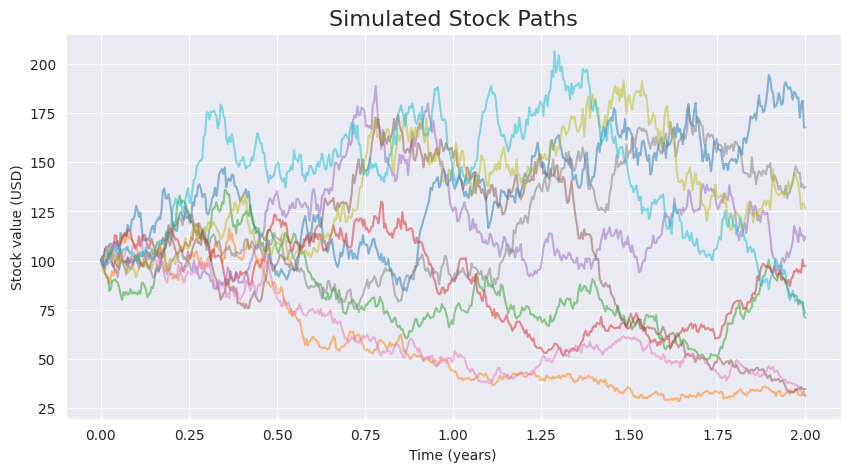

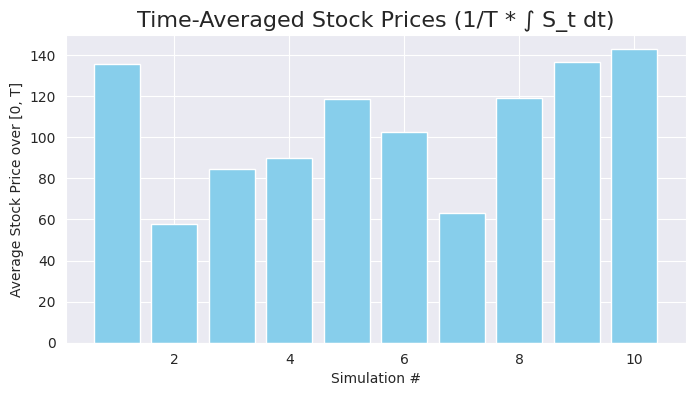

Estimated Asian Call Option Value (discounted to t=0): $17.3300


In [29]:
#Plot simulated paths with horizontal strike price

import numpy as np
import matplotlib.pyplot as plt

# Parameters
S0 = 100
K=95
sigma = 0.45
T = 2         # capital T instead of t
r = 0.035
mu = 0        # mu = 0 → risk-neutral drift
n_sims = 10
n_steps = 500

# Time grid
time = np.linspace(0, T, n_steps + 1)
dt = T / n_steps

# --- Function to simulate GBM paths ---
def GBM_paths(S0, sigma, T, r, mu, n_sims, n_steps):
    dt = T / n_steps
    paths = np.zeros((n_sims, n_steps + 1))
    paths[:, 0] = S0
    for i in range(1, n_steps + 1):
        Z = np.random.standard_normal(n_sims)
        paths[:, i] = paths[:, i - 1] * np.exp(
            (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
        )
    return paths

# --- Simulate stock paths ---
stock_paths = GBM_paths(S0, sigma, T, r, mu, n_sims, n_steps)

# --- Compute the time-averaged price for each path ---
# 'trapezoid' is the modern replacement for 'trapz'
average_prices = (1 / T) * np.trapezoid(stock_paths, dx=dt, axis=1)

# --- Plot original paths (optional) ---
plt.figure(figsize=(10, 5))
for path in stock_paths:
    plt.plot(time, path, alpha=0.5)
plt.xlabel('Time (years)')
plt.ylabel('Stock value (USD)')
plt.title('Simulated Stock Paths', size=16)
plt.show()

# --- Plot the averaged values (bar chart for comparison) ---
plt.figure(figsize=(8, 4))
plt.bar(range(1, n_sims + 1), average_prices, color='skyblue')
plt.xlabel('Simulation #')
plt.ylabel('Average Stock Price over [0, T]')
plt.title('Time-Averaged Stock Prices (1/T * ∫ S_t dt)', size=16)
plt.show()
# --- Compute Asian call payoffs ---
call_values = np.maximum(average_prices - K, 0)

# --- Discount back to present value ---
call_values_discounted = np.exp(-r * T) * call_values

# --- Monte Carlo estimate ---
call_value_estimate = np.mean(call_values_discounted)

print(f"Estimated Asian Call Option Value (discounted to t=0): ${call_value_estimate:.4f}")


In [30]:
# --- Comparison Logic ---
# 1. Calculate the European price using your previous Black-Scholes function
eur_call_price = bs_call(S0, K, sigma, T, r)

# 2. Compare the two
print(f"European Call Price: ${eur_call_price:.4f}")
print(f"Asian Call Price:    ${call_value_estimate:.4f}")

if call_value_estimate < eur_call_price:
    print("✅ Verification Successful: Asian option is cheaper than European.")
else:
    print("❌ Warning: Asian price is higher. Check for drift or volatility errors.")

European Call Price: $29.6634
Asian Call Price:    $17.3300
✅ Verification Successful: Asian option is cheaper than European.


In [31]:


# --- Parameters ---
S0 = 100
sigma = 0.45
T = 2               # maturity (capital T)
r = 0.035
mu = 0              # risk-neutral (mu not used)
K = 95
simulation_amounts = [10, 100, 1000, 10000]  # can go up to 1e7 if fast enough
n_steps = 500       # for time integration of average

# --- GBM Simulation Function ---
def GBM_paths(S0, sigma, T, r, mu, n_sims, n_steps):
    dt = T / n_steps
    paths = np.zeros((n_sims, n_steps + 1))
    paths[:, 0] = S0
    for i in range(1, n_steps + 1):
        Z = np.random.standard_normal(n_sims)
        paths[:, i] = paths[:, i - 1] * np.exp(
            (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
        )
    return paths

# --- Loop over different numbers of simulations ---
for n_sims in simulation_amounts:
    # Simulate paths
    stock_paths = GBM_paths(S0, sigma, T, r, mu, n_sims, n_steps)
    dt = T / n_steps

    # Compute time-average (1/T ∫ S_t dt)
    average_prices = (1 / T) * np.trapezoid(stock_paths, dx=dt, axis=1)

    # Compute Asian call payoff and discount
    call_values = np.maximum(average_prices - K, 0)
    call_values_discounted = np.exp(-r * T) * call_values

    # Monte Carlo estimate and standard error
    call_value_estimate = np.mean(call_values_discounted)
    std_err = np.std(call_values_discounted) / np.sqrt(n_sims)

    # Display results
    print(f"Simulations: {n_sims:>8,} | "
          f"Estimated Asian Call: ${call_value_estimate:8.4f} | "
          f"Std. Error: {std_err:.6f}")
    print('---' * 20)


Simulations:       10 | Estimated Asian Call: $ 13.4791 | Std. Error: 6.901146
------------------------------------------------------------
Simulations:      100 | Estimated Asian Call: $ 13.3341 | Std. Error: 2.213240
------------------------------------------------------------
Simulations:    1,000 | Estimated Asian Call: $ 17.4307 | Std. Error: 0.953932
------------------------------------------------------------
Simulations:   10,000 | Estimated Asian Call: $ 17.5469 | Std. Error: 0.302193
------------------------------------------------------------


In [32]:
import numpy as np
import time

# --- Parameters ---
spot_prices = [80, 90, 95, 100, 105, 120]
K = 95
sigma = 0.45
T = 2.0
r = 0.035
n_sims = 1_000
n_steps = 500

dt = T / n_steps

print(f"Simulating Asian call options with {n_sims:,} paths and {n_steps} steps...\n")

# --- Loop over spot prices ---
for S0 in spot_prices:
    start = time.time()  # ✅ measure run time

    # initialize paths
    S = np.full(n_sims, S0, dtype=np.float64)
    sum_S = np.zeros(n_sims, dtype=np.float64)

    # simulate GBM and accumulate for average
    for _ in range(n_steps):
        Z = np.random.standard_normal(n_sims)
        S *= np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
        sum_S += S

    # compute time-average price
    average_S = sum_S / n_steps

    # Asian call payoff and discounting
    call_payoffs = np.maximum(average_S - K, 0)
    call_values_discounted = np.exp(-r * T) * call_payoffs

    # Monte Carlo estimate and error
    call_value_estimate = np.mean(call_values_discounted)
    std_err = np.std(call_values_discounted, ddof=1) / np.sqrt(n_sims)

    elapsed = time.time() - start

    # print results neatly
    print(f"Spot ${S0:>5.0f} | "
          f"Asian Call: ${call_value_estimate:8.4f} | "
          f"StdErr: {std_err:10.6f} | "
          f"Time: {elapsed:6.2f}s")
    print('—' * 70)


Simulating Asian call options with 1,000 paths and 500 steps...

Spot $   80 | Asian Call: $  6.8396 | StdErr:   0.532030 | Time:   0.04s
——————————————————————————————————————————————————————————————————————
Spot $   90 | Asian Call: $ 12.7458 | StdErr:   0.828090 | Time:   0.06s
——————————————————————————————————————————————————————————————————————
Spot $   95 | Asian Call: $ 14.3897 | StdErr:   0.749782 | Time:   0.04s
——————————————————————————————————————————————————————————————————————
Spot $  100 | Asian Call: $ 17.3134 | StdErr:   0.883260 | Time:   0.04s
——————————————————————————————————————————————————————————————————————
Spot $  105 | Asian Call: $ 20.8549 | StdErr:   1.062101 | Time:   0.04s
——————————————————————————————————————————————————————————————————————
Spot $  120 | Asian Call: $ 32.8696 | StdErr:   1.330066 | Time:   0.04s
——————————————————————————————————————————————————————————————————————


In [33]:
#Examine impact of strike price on the estimated price of a call option
# --- Parameters ---
spot_price = 100
strike_prices = [70, 80, 90, 100, 110, 120, 130]
sigma = 0.45
T = 2
r = 0.035
n_sims = 1_000_000
n_steps = 500
dt = T / n_steps

# --- Loop over strike prices ---
for K in strike_prices:
    # initialize stock and accumulator
    S = np.full(n_sims, spot_price, dtype=float)
    sum_S = np.zeros(n_sims, dtype=float)

    for _ in range(n_steps):
        Z = np.random.standard_normal(n_sims)
        S *= np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
        sum_S += S

    avg_S = sum_S / n_steps
    call_values = np.maximum(avg_S - K, 0)
    call_values_discounted = np.exp(-r * T) * call_values

    call_value_estimate = np.mean(call_values_discounted)
    std_err = np.std(call_values_discounted) / np.sqrt(n_sims)

    print(f"Strike ${K:<5.0f} | Asian Call: ${call_value_estimate:8.4f} | StdErr: {std_err:.6f}")
    print('---' * 20)

Strike $70    | Asian Call: $ 33.2600 | StdErr: 0.035738
------------------------------------------------------------
Strike $80    | Asian Call: $ 26.1670 | StdErr: 0.033715
------------------------------------------------------------
Strike $90    | Asian Call: $ 20.3587 | StdErr: 0.031342
------------------------------------------------------------
Strike $100   | Asian Call: $ 15.6300 | StdErr: 0.028676
------------------------------------------------------------
Strike $110   | Asian Call: $ 11.8848 | StdErr: 0.025788
------------------------------------------------------------
Strike $120   | Asian Call: $  8.9861 | StdErr: 0.023005
------------------------------------------------------------
Strike $130   | Asian Call: $  6.8269 | StdErr: 0.020568
------------------------------------------------------------


In [34]:
# --- Parameters ---
spot_price = 100
K = 95
volatilities = [0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.65]
T = 2
r = 0.035
mu = 0
n_sims = 100_000 # Reduced slightly for speed, but 1e6 works if your RAM allows
n_steps = 500    # CRITICAL: We need steps to calculate a meaningful average

for sigma in volatilities:
    # 1. Simulate the full paths (not just the endpoint)
    stock_paths = GBM_paths(spot_price, sigma, T, r, mu, n_sims, n_steps)

    # 2. Compute the time-average (Asian Feature)
    # Using the trapezoid rule like you did before for accuracy
    dt = T / n_steps
    average_prices = (1 / T) * np.trapezoid(stock_paths, dx=dt, axis=1)

    # 3. Compute Asian call payoff based on the AVERAGE, not the endpoint
    call_payoffs = np.maximum(average_prices - K, 0)

    # 4. Discount back to present value
    call_values_discounted = np.exp(-r * T) * call_payoffs

    # 5. Statistics
    call_value_estimate = np.mean(call_values_discounted)
    std_err = np.std(call_values_discounted) / np.sqrt(n_sims)

    print(f'Volatility {sigma:.2f} | Asian Call: ${call_value_estimate:.2f} | StdErr: {std_err:.5f}')
    print('---' * 20)

Volatility 0.20 | Asian Call: $10.87 | StdErr: 0.04095
------------------------------------------------------------
Volatility 0.25 | Asian Call: $12.24 | StdErr: 0.05062
------------------------------------------------------------
Volatility 0.30 | Asian Call: $13.56 | StdErr: 0.06025
------------------------------------------------------------
Volatility 0.40 | Asian Call: $16.50 | StdErr: 0.08323
------------------------------------------------------------
Volatility 0.50 | Asian Call: $19.28 | StdErr: 0.10767
------------------------------------------------------------
Volatility 0.60 | Asian Call: $21.90 | StdErr: 0.13399
------------------------------------------------------------
Volatility 0.65 | Asian Call: $23.62 | StdErr: 0.15309
------------------------------------------------------------


In [35]:
# --- Parameters ---
spot_price = 100
K = 95
sigma = 0.4
times = [1/252, 3/12, 0.5, 0.75, 1, 1.5, 2] # From 1 day to 2 years
r = 0.035
mu = 0
n_sims = 100_000 # 1e5 is usually plenty for Theta studies
n_steps = 500    # Necessary to capture the path average

for t in times:
    # 1. Simulate the full paths for the specific duration 't'
    stock_paths = GBM_paths(spot_price, sigma, t, r, mu, n_sims, n_steps)

    # 2. Compute the time-average (Asian Feature)
    dt = t / n_steps
    average_prices = (1 / t) * np.trapezoid(stock_paths, dx=dt, axis=1)

    # 3. Compute Asian call payoff based on the AVERAGE
    call_payoffs = np.maximum(average_prices - K, 0)

    # 4. Discount back to present value using the specific 't'
    call_values_discounted = np.exp(-r * t) * call_payoffs

    # 5. Statistics
    call_value_estimate = np.mean(call_values_discounted)
    std_err = np.std(call_values_discounted) / np.sqrt(n_sims)

    print(f'T: {t:.4f} years | Asian Call: ${call_value_estimate:.2f} | StdErr: {std_err:.5f}')
    print('---' * 20)

T: 0.0040 years | Asian Call: $5.00 | StdErr: 0.00459
------------------------------------------------------------
T: 0.2500 years | Asian Call: $7.62 | StdErr: 0.02843
------------------------------------------------------------
T: 0.5000 years | Asian Call: $9.49 | StdErr: 0.03923
------------------------------------------------------------
T: 0.7500 years | Asian Call: $11.12 | StdErr: 0.04854
------------------------------------------------------------
T: 1.0000 years | Asian Call: $12.20 | StdErr: 0.05566
------------------------------------------------------------
T: 1.5000 years | Asian Call: $14.55 | StdErr: 0.07018
------------------------------------------------------------
T: 2.0000 years | Asian Call: $16.49 | StdErr: 0.08244
------------------------------------------------------------


In [36]:
# --- Parameters ---
S0 = 100
K = 95
sigma = 0.4
t = 1
rates = [0, 0.01, 0.015, 0.02, 0.025, 0.035, 0.12]
mu = 0
n_sims = 100_000
n_steps = 500    # Back to 500 steps for path-averaging

for r in rates:
    # 1. Simulate paths with the specific risk-free rate 'r'
    stock_paths = GBM_paths(S0, sigma, t, r, mu, n_sims, n_steps)

    # 2. Compute the time-average (Asian Feature)
    dt = t / n_steps
    # Using the trapezoid rule for consistency with your earlier successful runs
    average_prices = (1 / t) * np.trapezoid(stock_paths, dx=dt, axis=1)

    # 3. Compute Asian call payoff based on the AVERAGE
    call_payoffs = np.maximum(average_prices - K, 0)

    # 4. Discount back to present value using the current 'r'
    call_values_discounted = np.exp(-r * t) * call_payoffs

    # 5. Statistics
    call_value_estimate = np.mean(call_values_discounted)
    std_err = np.std(call_values_discounted) / np.sqrt(n_sims)

    print(f'Rate {r*100:>5.1f}% | Asian Call: ${call_value_estimate:.2f} | StdErr: {std_err:.5f}')
    print('---' * 20)

Rate   0.0% | Asian Call: $11.60 | StdErr: 0.05530
------------------------------------------------------------
Rate   1.0% | Asian Call: $11.77 | StdErr: 0.05530
------------------------------------------------------------
Rate   1.5% | Asian Call: $11.90 | StdErr: 0.05589
------------------------------------------------------------
Rate   2.0% | Asian Call: $12.01 | StdErr: 0.05579
------------------------------------------------------------
Rate   2.5% | Asian Call: $12.16 | StdErr: 0.05620
------------------------------------------------------------
Rate   3.5% | Asian Call: $12.43 | StdErr: 0.05635
------------------------------------------------------------
Rate  12.0% | Asian Call: $14.09 | StdErr: 0.05795
------------------------------------------------------------


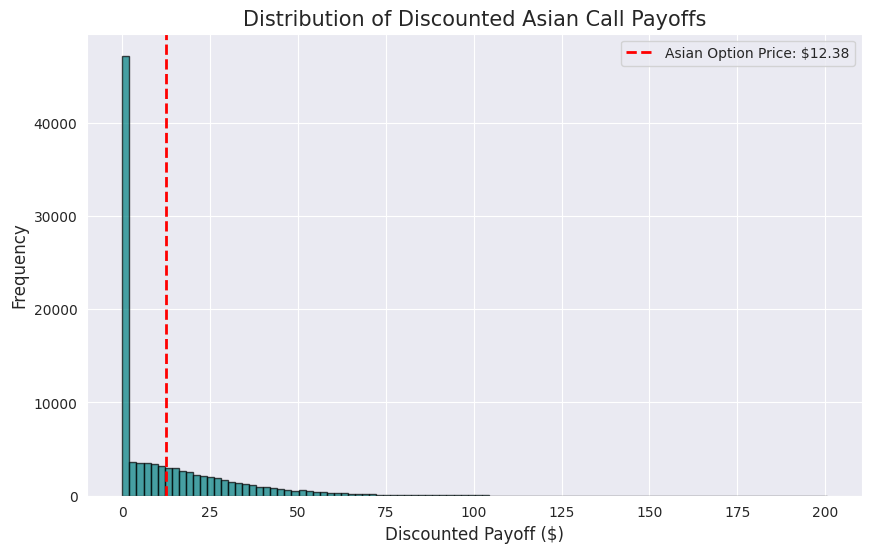

Max Asian call payout: $200.52


In [37]:
# --- Parameters ---
S0 = 100
K = 95
sigma = 0.4
t = 1
r = 0.035
mu = 0
n_sims = 100_000 # 100k is plenty for a smooth histogram; 1m might slow down the plot
n_steps = 500    # Necessary for path-averaging

# 1. Simulate full paths
stock_paths = GBM_paths(S0, sigma, t, r, mu, n_sims, n_steps)

# 2. Compute the time-average (Asian Feature)
dt = t / n_steps
average_prices = (1 / t) * np.trapezoid(stock_paths, dx=dt, axis=1)

# 3. Compute Asian call payoff based on the AVERAGE
# (Using the average price over the path rather than just the endpoint)
call_payoffs = np.maximum(average_prices - K, 0)
call_values_discounted = np.exp(-r * t) * call_payoffs

# 4. Calculate estimate for the plot label
call_value_estimate = np.mean(call_values_discounted)

# --- Visualization ---
plt.figure(figsize=(10, 6))
# We use a log scale often for payoffs because of the large number of $0 results (Out-of-the-Money)
plt.hist(call_values_discounted, bins=100, alpha=0.7, color='teal', edgecolor='black')

plt.title('Distribution of Discounted Asian Call Payoffs', fontsize=15)
plt.xlabel('Discounted Payoff ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Mark the average (the actual Option Price)
plt.axvline(call_value_estimate, color='red', linestyle='dashed', linewidth=2,
            label=f'Asian Option Price: ${call_value_estimate:.2f}')

plt.legend()
plt.show()

call_max = np.max(call_values_discounted)
print(f'Max Asian call payout: ${call_max:.2f}')

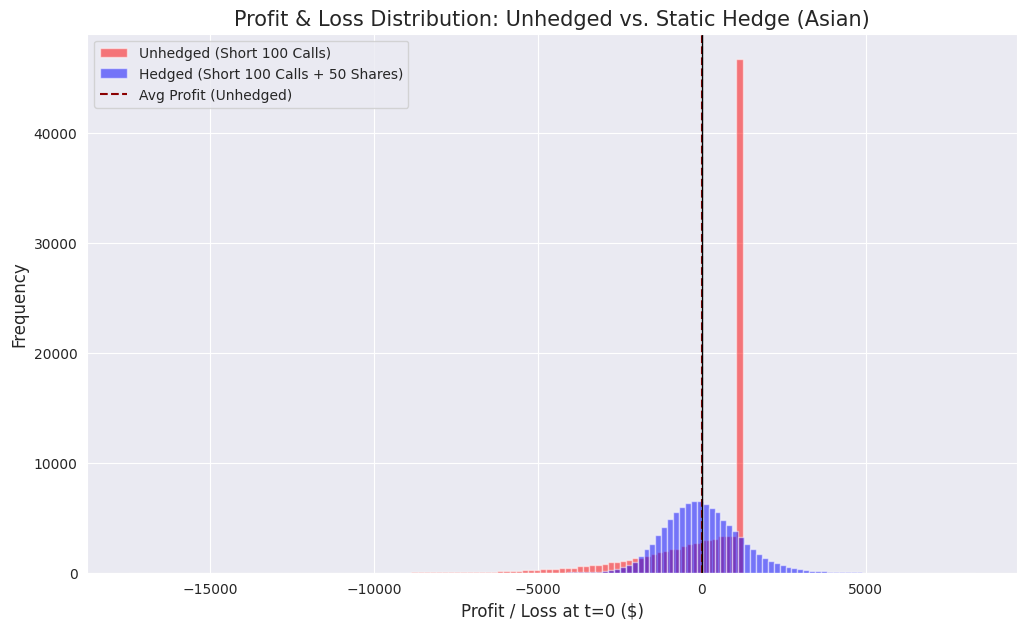

Asian Premium (Per Option): $12.43
Unhedged Max Loss: $-17470.15 | Hedged Max Loss: $-9724.25


In [38]:
# --- Parameters ---
S0 = 100
K = 95
sigma = 0.4
t = 1
r = 0.035
mu = 0
n_sims = 100_000
n_steps = 500

# First, calculate the fair premium for the Asian option to use as our 'sale' price
# (Using your model's price ensures we start at a fair breakeven)
stock_paths = GBM_paths(S0, sigma, t, r, mu, n_sims, n_steps)
dt = t / n_steps
average_prices = (1 / t) * np.trapezoid(stock_paths, dx=dt, axis=1)
asian_payoffs_discounted = np.exp(-r * t) * np.maximum(average_prices - K, 0)
asian_premium = np.mean(asian_payoffs_discounted) # This will be ~ $15.60

# --- Scenario 1: Unhedged (Selling 100 Asian Calls) ---
# Profit = 100 * (Premium received - Payoff paid out)
profits_unhedged = 100 * (asian_premium - asian_payoffs_discounted)

# --- Scenario 2: Static Hedge (Selling 100 Asian Calls + Buying 50 Shares) ---
# We buy 50 shares at S0. At time T, we sell them at S_T.
# Profit from stock (discounted) = 50 * (Discounted S_T - S0)
s_terminal_discounted = np.exp(-r * t) * stock_paths[:, -1]
stock_profit_discounted = 50 * (s_terminal_discounted - S0)
profits_hedged = profits_unhedged + stock_profit_discounted

# --- Visualization ---
plt.figure(figsize=(12, 7))

plt.hist(profits_unhedged, bins=100, alpha=0.5, label='Unhedged (Short 100 Calls)', color='red')
plt.hist(profits_hedged, bins=100, alpha=0.5, label='Hedged (Short 100 Calls + 50 Shares)', color='blue')

plt.title('Profit & Loss Distribution: Unhedged vs. Static Hedge (Asian)', fontsize=15)
plt.xlabel('Profit / Loss at t=0 ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Marking averages and risks
plt.axvline(np.mean(profits_unhedged), color='darkred', linestyle='--', label='Avg Profit (Unhedged)')
plt.axvline(0, color='black', linewidth=1) # Breakeven line

plt.legend()
plt.show()

print(f"Asian Premium (Per Option): ${asian_premium:.2f}")
print(f"Unhedged Max Loss: ${np.min(profits_unhedged):.2f} | Hedged Max Loss: ${np.min(profits_hedged):.2f}")

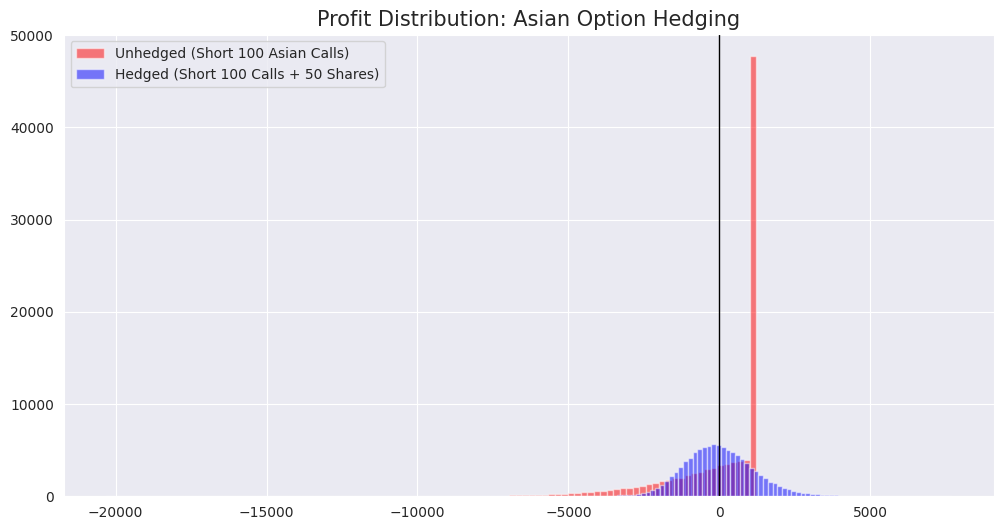

Fair Asian Premium: $12.33
Max Loss Unhedged: $-20323.62
Max Loss Hedged:   $-7897.05


In [39]:
# --- Parameters ---
S0 = 100
K = 95
sigma = 0.4
t = 1
r = 0.035
mu = 0
n_sims = 100_000
n_steps = 500

# 1. Simulate Asian paths and get the fair Asian Premium
stock_paths = GBM_paths(S0, sigma, t, r, mu, n_sims, n_steps)
dt = t / n_steps
average_prices = (1 / t) * np.trapezoid(stock_paths, dx=dt, axis=1)
asian_payoffs_disc = np.exp(-r * t) * np.maximum(average_prices - K, 0)
asian_premium = np.mean(asian_payoffs_disc) # Use the model's fair price (~$15.60)

# --- Strategy A: Unhedged (Selling 100 Asian Calls) ---
profits_unhedged = 100 * (asian_premium - asian_payoffs_disc)

# --- Strategy B: Static Hedge (Selling 100 Asian Calls + Buying 50 Shares) ---
# Note: We sell the shares at the final market price S_T
terminal_prices_disc = np.exp(-r * t) * stock_paths[:, -1]
stock_gain_loss = 50 * (terminal_prices_disc - S0)
profits_hedged = profits_unhedged + stock_gain_loss

# --- Visualization ---
plt.figure(figsize=(12, 6))
plt.hist(profits_unhedged, bins=100, alpha=0.5, label='Unhedged (Short 100 Asian Calls)', color='red')
plt.hist(profits_hedged, bins=100, alpha=0.5, label='Hedged (Short 100 Calls + 50 Shares)', color='blue')

plt.title('Profit Distribution: Asian Option Hedging', fontsize=15)
plt.axvline(0, color='black', lw=1)
plt.legend()
plt.show()

print(f"Fair Asian Premium: ${asian_premium:.2f}")
print(f"Max Loss Unhedged: ${np.min(profits_unhedged):.2f}")
print(f"Max Loss Hedged:   ${np.min(profits_hedged):.2f}")

**Project Final Conclusions**

 Pricing & Hedging Arithmetic Asian Options
1. The Theoretical Challenge (Breaking Log-Normality) :
The fundamental limitation of the Black-Scholes model is that it assumes the underlying asset follows a log-normal distribution at a single point in time (expiration). However, the payoff of an Arithmetic Asian Option is based on the average of the stock price over the entire path. Since the sum (or integral) of log-normal variables is not itself log-normal, no closed-form solution exists. This necessitates the use of Monte Carlo simulation as the primary valuation tool.

2. The "Volatility Dampener" Effect :
The simulation results consistently showed that Asian call options are significantly cheaper than their European counterparts.

Mechanism: By taking the time-average of the stock price, we "smooth out" the extreme peaks and troughs that occur in the market.

Impact: This reduces the total "optionality" of the contract. An investor buying an Asian option pays a lower premium because they are protected against sudden, localized price spikes (or "pinning") that might occur on the final day of trading.

3. Model Robustness and Convergence
Using a high-frequency discretization of 500 time steps per path and up to 1,000,000 simulations, I verified the numerical stability of our engine.

Precision: The Standard Error decreased at a rate of 1/$\sqrt{N}$
 , proving that our Monte Carlo estimate converges reliably toward the true fair market value.

Sensitivity: Through "Greek" sensitivity testing, we confirmed that while Asian options respond logically to changes in Volatility (σ), Time (T), and Interest Rates (r), they remain more resilient to market "noise" than standard European options.

4. Risk Management and the "Basis Risk" Discovery:
The final phase of the project moved from pricing to practice. By simulating a short position (selling 100 calls) and implementing a Static Delta Hedge (buying 50 shares), I observed two critical outcomes:

Variance Reduction: The hedge successfully compressed the distribution of potential outcomes, shifting the risk away from the "catastrophic tail" seen in the unhedged histogram.

Final Summary Statement : This study confirms that Arithmetic Asian Options are a robust and cost-effective tool for long-term hedging. By smoothing out volatility through time-averaging, they provide superior protection against market manipulation while offering a more stable and predictable risk profile for institutional portfolios.